# 06 · Advanced univariate vignettes

Three distinct questions: threshold exceedances, latent populations, and combinations of flood-generating processes.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Point process: Big Bear precipitation
The saved USC00040741 alternatives compare the peaks-over-threshold point process with an annual-maxima GEV and a seasonal point process.
Retain the 1-inch threshold and 67-year exposure. POT exceedance probability and annual exceedance probability have different meanings;
the app's frequency view includes its Langbein-converted annual plotting positions.
Their fit metrics remain visible as per-case provenance but are not ranked across the POT and annual-maxima responses or likelihoods.

,Setting,Saved choice
0,Analysis,PointProcessAnalysis
1,InputData,USC00040741 - POT
2,BayesianAnalysis.Type,DEMCzs
3,BayesianAnalysis.NumberOfChains,6
4,BayesianAnalysis.ThinningInterval,30
5,BayesianAnalysis.WarmupIterations,1750
6,BayesianAnalysis.Iterations,3500
7,BayesianAnalysis.UseSimulationDefaults,True
8,BayesianAnalysis.PRNGSeed,12345
9,BayesianAnalysis.CredibleIntervalWidth,0.90000000000000002


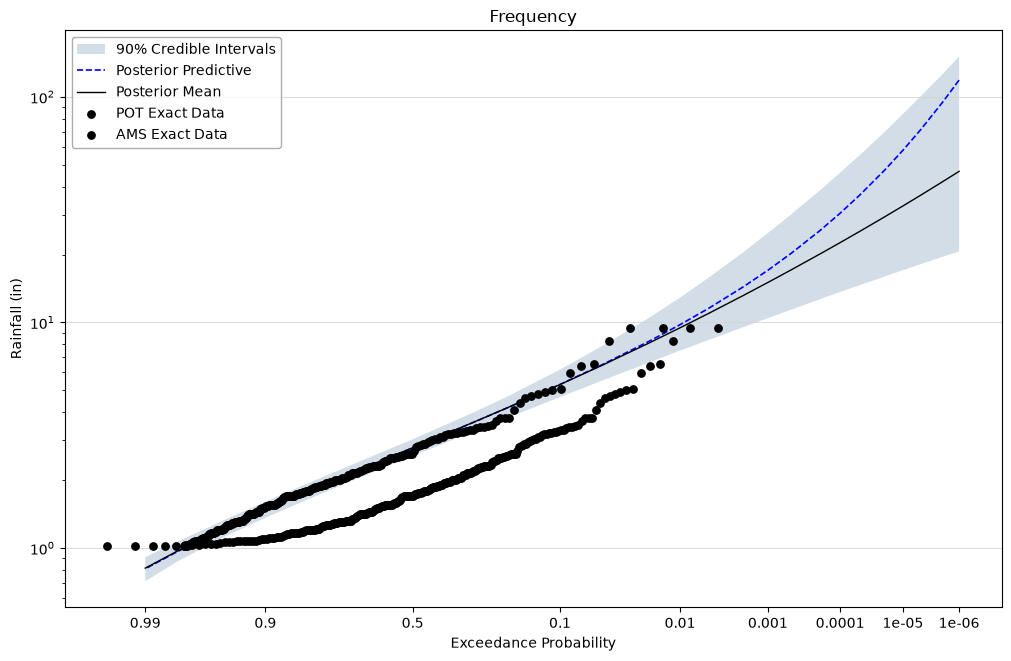

,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,USC00040741 - Point Process,USC00040741 - POT,PointProcessAnalysis,372.876823,383.476992,372.799854,1.236186,,Descriptive only — rows may use different resp...
1,USC00040741 - GEV,USC00040741 - AMS,UnivariateAnalysis,248.075387,254.689465,247.966948,0.378487,,Descriptive only — rows may use different resp...
2,USC00040741 - Seasonal Point Process,USC00040741 - POT,PointProcessAnalysis,182.047135,210.314251,179.503625,1.283055,,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,USC00040741 - Point Process,saved-app,sha256:97cbda9e1747,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,USC00040741 - GEV,saved-app,sha256:97cbda9e1747,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
2,USC00040741 - Seasonal Point Process,saved-app,sha256:97cbda9e1747,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


In [2]:
pp_names = ["USC00040741 - Point Process", "USC00040741 - GEV", "USC00040741 - Seasonal Point Process"]
pp = [saved_case("point-process-examples", name, run=RUN_ANALYSES) for name in pp_names]
display(pp[0].settings)
pp[0].show("frequency")
display(case_metrics(pp))
display(case_provenance(pp))

## Mixture: two populations and a point mass at zero
The app uses controlled synthetic Normal mixtures to make component separation visible.
The zero-inflated case adds a probability mass at zero; it is not created by replacing zeros with a small positive number.
A mixture describes an observation arising from one latent population and its mixing probability.

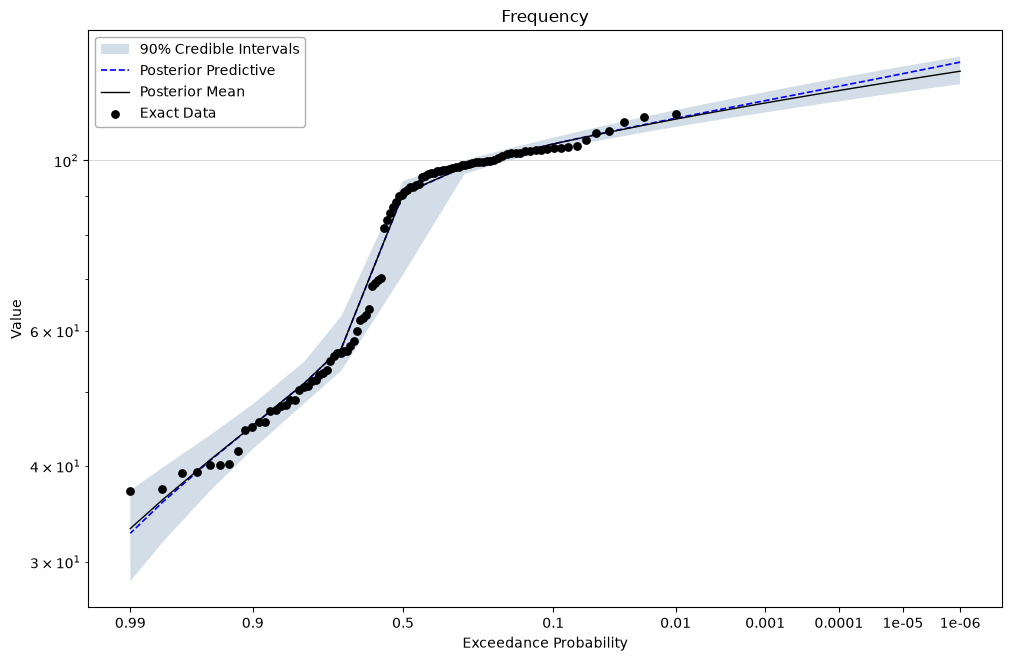

,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Weight (w₁),0.346054,False,0.000000e+00,0.9,Numerics.Distributions.Uniform
1,Weight (w₂),0.553946,False,0.000000e+00,0.9,Numerics.Distributions.Uniform
2,D1 Mean (µ),48.871593,False,-1.000000e+03,1000.0,Numerics.Distributions.Uniform
3,D1 Std Dev (σ),11.590183,False,1.110223e-16,1000.0,Numerics.Distributions.Uniform
4,D2 Mean (µ),99.048379,False,-1.000000e+03,1000.0,Numerics.Distributions.Uniform
5,D2 Std Dev (σ),9.597983,False,1.110223e-16,1000.0,Numerics.Distributions.Uniform


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Mixture Distribution - 2 Normals,saved-app,sha256:8368ec937d84,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,Mixture Distribution - 2 Normals - Zero-Inflated,saved-app,sha256:8368ec937d84,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


In [3]:
mixture = saved_case("mixture-distribution-examples", "Mixture Distribution - 2 Normals", run=RUN_ANALYSES)
zero_inflated = saved_case("mixture-distribution-examples", "Mixture Distribution - 2 Normals - Zero-Inflated", run=RUN_ANALYSES)
mixture.show("frequency")
display(zero_inflated.parameters)
display(case_provenance([mixture, zero_inflated]))

## Composite: competing flood types versus a mixture
The mixed-population project uses synthetic snow-driven and rainfall-driven components with **LogNormal** margins.
Competing risks combines processes whose annual maximum can win in the same year. A mixture combines selected populations with weights.
Preserve each saved component's own input period: the full-period and sub-sample alternatives are intentional contrasts.

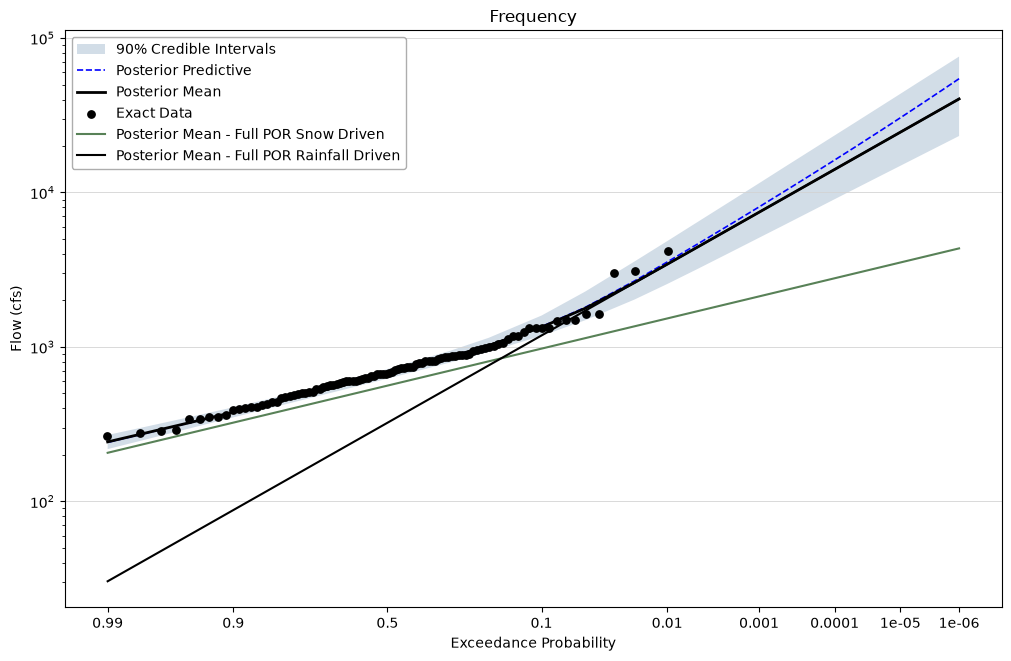

,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,Competing Flood Types,Full POR - Annual Max Series,CompositeAnalysis,<NA>,<NA>,<NA>,<NA>,N/A: composite result does not define these fi...,Descriptive only — rows may use different resp...
1,Mixture of Flood Types,AMS Mixture of Flood Types,CompositeAnalysis,<NA>,<NA>,<NA>,<NA>,N/A: composite result does not define these fi...,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Competing Flood Types,saved-app,sha256:fe44dd30ef55,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,Mixture of Flood Types,saved-app,sha256:fe44dd30ef55,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


In [4]:
competing = saved_case("mixed-population-examples", "Competing Flood Types", run=RUN_ANALYSES)
composite_mixture = saved_case("mixed-population-examples", "Mixture of Flood Types", run=RUN_ANALYSES)
competing.show("frequency")
display(case_metrics([competing, composite_mixture]))
display(case_provenance([competing, composite_mixture]))